**Goal**: Evaluate the impact of including spatial features as additional input channels on the prediction of t_ref(t).

**Architecture**: `baseline_batchnorm_sampling` model from phase1.ipynb <br>
**Output channels**: 1 <br>
**Number of epochs**: 50 <br>
**Batch Size**: 32 <br>
**Learning Rate**: 0.001 <br>

**Input configurations by step:** <br>
- Step 0: ['t_ref(t-3)', 't_ref(t-2)', 't_ref(t-1)', 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'] <br>
- Step 1: ['t_ref(t-3)', 't_ref(t-2)', 't_ref(t-1)', 'lat_sin', 'lat_cos']  <br>
- Step 2: ['t_ref(t-3)', 't_ref(t-2)', 't_ref(t-1)]  <br>

In [1]:
from utils.utils import VarSet, DataSet
from architectures.cnn_baseline import CNN2D, set_seed, Results

num_epochs = 50
set_seed()

t_ref = VarSet(
    var_name="t_ref",
    file_name="PP_DATA/t_ref.192101-201012.nc",
    is_output=True
)

spatial_features = VarSet(
    var_name="spatial_features",
    file_name="PP_DATA/spatial_features.nc",
    is_static=True
)

spatial_features_latonly = VarSet(
    var_name="spatial_features",
    file_name="PP_DATA/spatial_features_latonly.nc",
    is_static=True
)

lon, lat = t_ref.get_grid()
time_test = t_ref.get_time('time_test')

In [2]:
variables = [t_ref, spatial_features]
data = DataSet(set_name="step0", variables=variables)
set_seed()
Step0 = CNN2D(data, case=2, label="Phase1a_step0")
Step0.train()

variables = [t_ref, spatial_features_latonly]
data = DataSet(set_name="step1", variables=variables)
set_seed()
Step1 = CNN2D(data, case=2, label="Phase1a_step1")
Step1.train()

variables = [t_ref]
data = DataSet(set_name="step2", variables=variables)
set_seed()
Step2 = CNN2D(data, case=2, label="Phase1a_step2")
Step2.train()

Phase1a_step0 - Sequential(
  (0): Conv2d(7, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (10): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): ConvTranspose2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (13): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU()
  (15): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), 

Phase1a_step0 - Doing inference for 117 time steps
Phase1a_step0-output - Size of the area weight:: (90, 90)
Phase1a_step0-output - Calculating RMSE for target: t_ref
Phase1a_step0-output - Global RMSE: t_ref :: 6.815621953693299
Phase1a_step1 - Doing inference for 117 time steps
Phase1a_step1-output - Size of the area weight:: (90, 90)
Phase1a_step1-output - Calculating RMSE for target: t_ref
Phase1a_step1-output - Global RMSE: t_ref :: 8.61263817681819
Phase1a_step2 - Doing inference for 117 time steps
Phase1a_step2-output - Size of the area weight:: (90, 90)
Phase1a_step2-output - Calculating RMSE for target: t_ref
Phase1a_step2-output - Global RMSE: t_ref :: 31.040153673254437


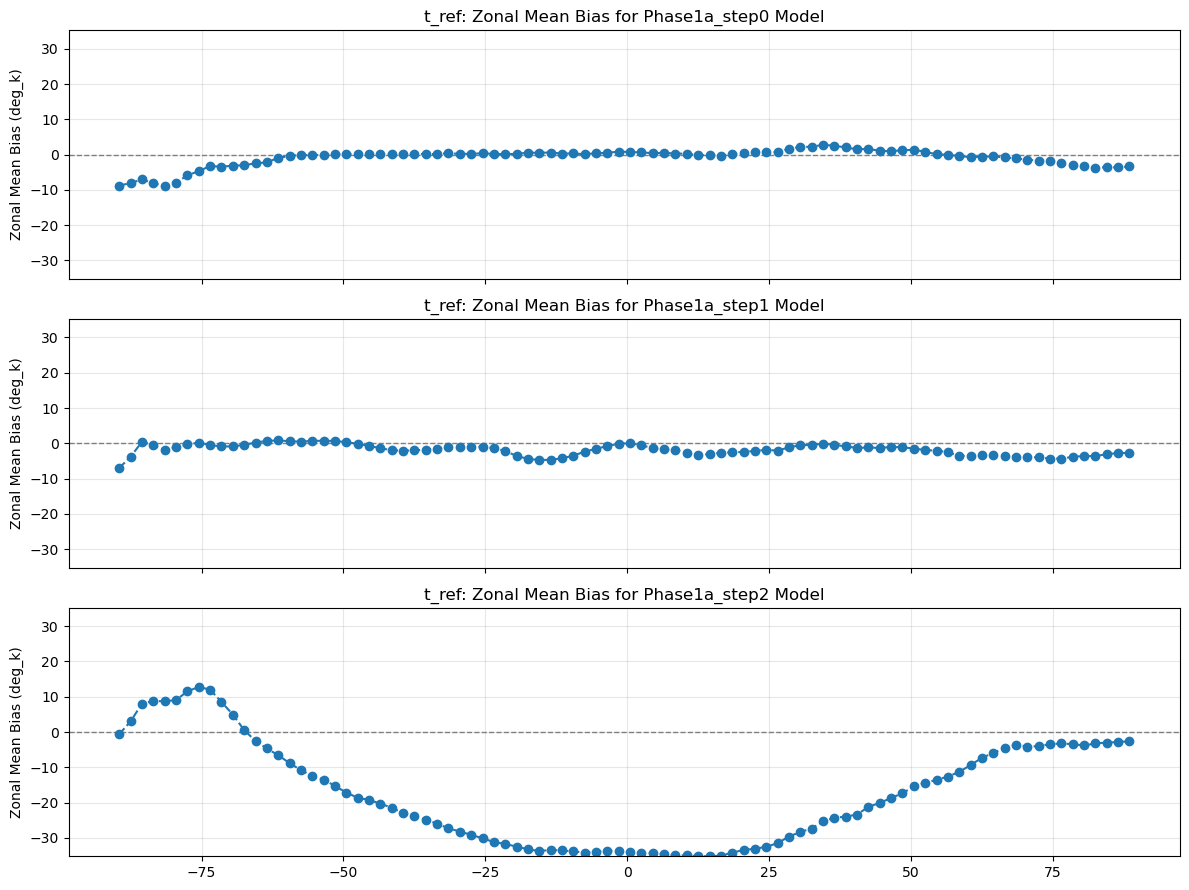

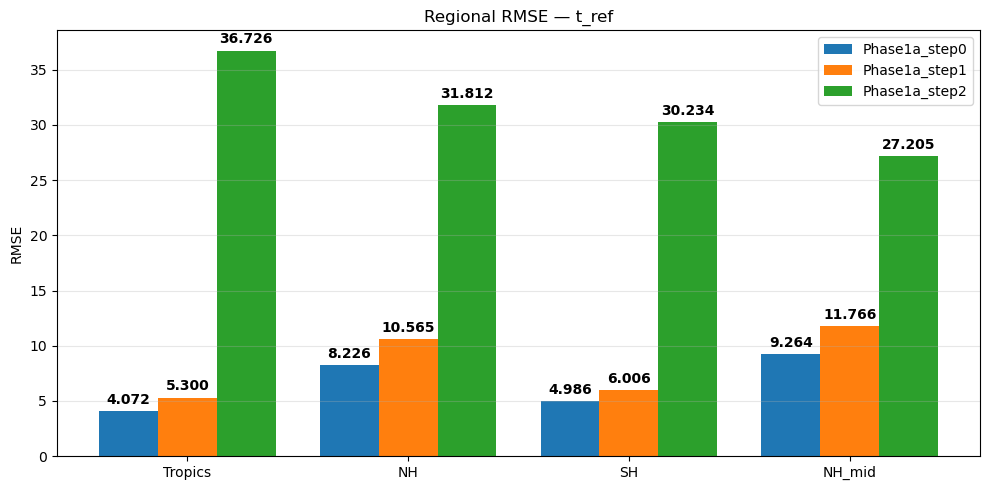

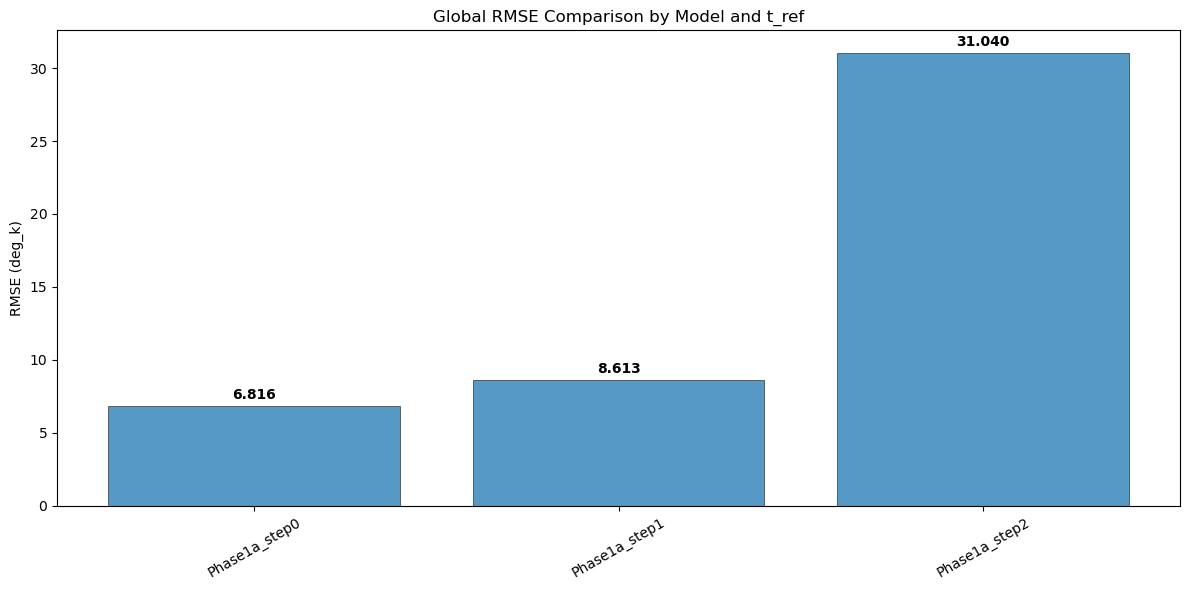

/net/unr/SPEAR_EMULATOR/architectures/cnn_baseline.py:646: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time_converted = time_test.to_index().to_datetimeindex()


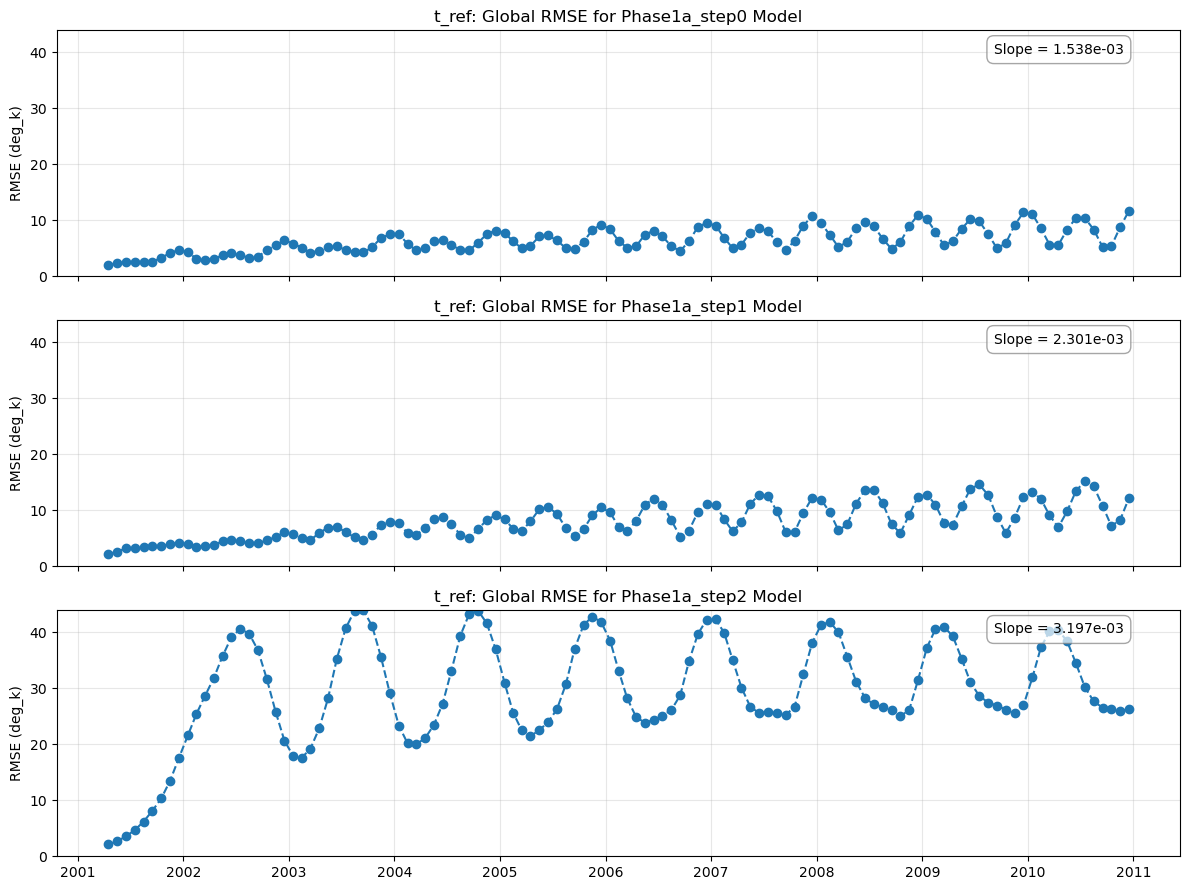

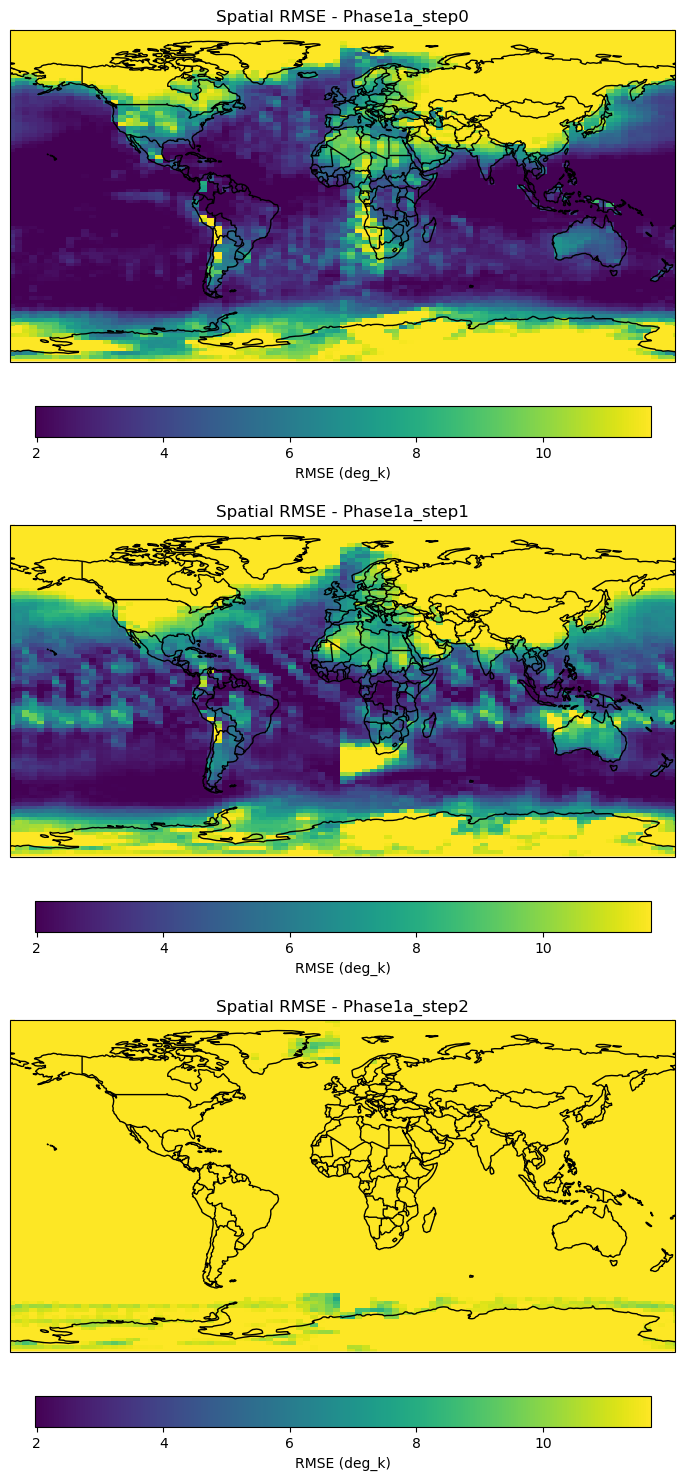

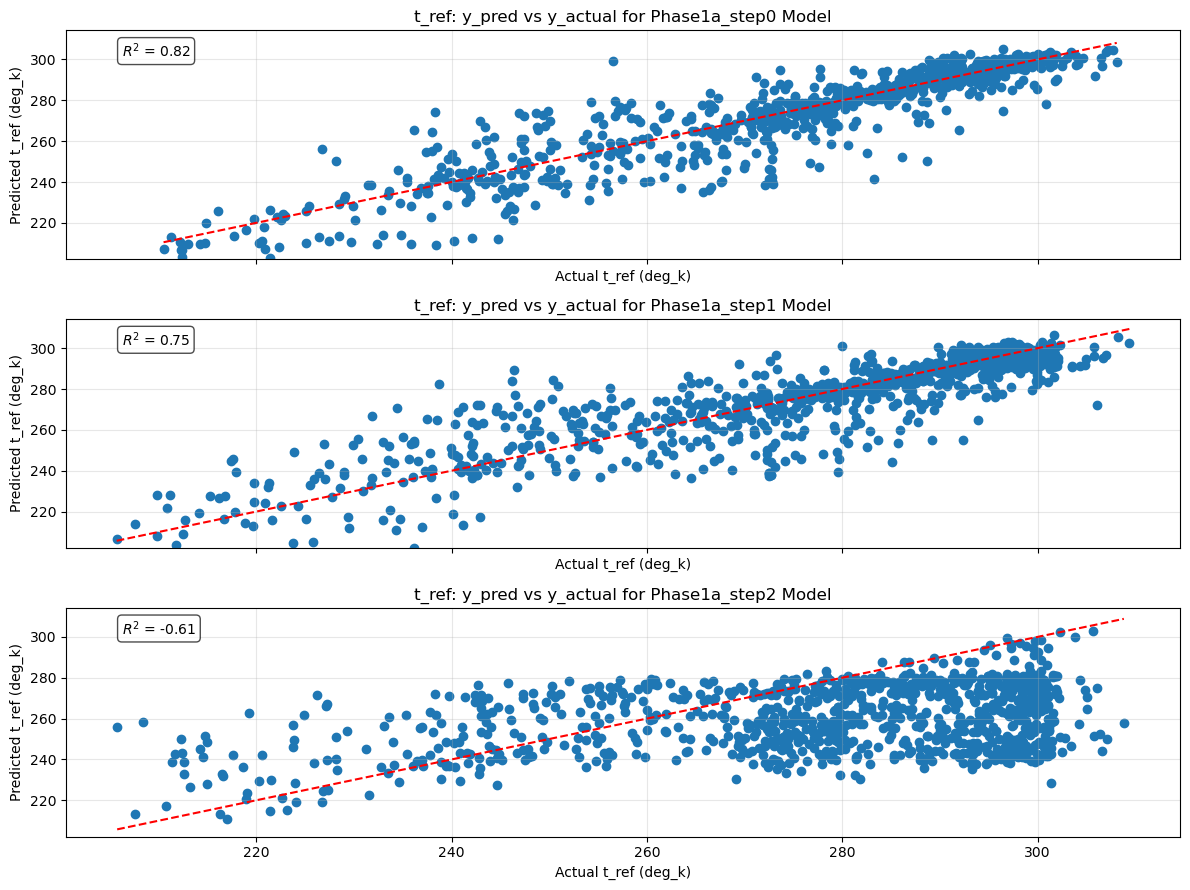

In [3]:
Model_results = Results(lon, lat)
Model_results.add_model_output(Step0, run_type="forecast_rollout")
Model_results.add_model_output(Step1, run_type="forecast_rollout")
Model_results.add_model_output(Step2, run_type="forecast_rollout")

Model_results.plot_zonal_bias('t_ref', lat)
Model_results.plot_regional_RMSE('t_ref')
Model_results.plot_global_RMSE('t_ref')
Model_results.plot_temporal_RMSE('t_ref', time_test)
Model_results.plot_spatial_RMSE("t_ref", lon, lat)
Model_results.plot_scatter_y_pred_vs_y_actual("t_ref")